# Are the contact maps correct?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SUMMARY_FILE = "/nfs/scratch/pdb_dimers/contact_maps/contact_map_summary.tsv"
INTERACTION_FILE = "/nfs/scratch/pdb_dimers/dataset_iterations/05_KaHIP_partitions.tsv"
SEQUENCE_FILE = "/nfs/scratch/pdb_dimers/unique_sequences_with_partitioning.tsv"
ENTITY_SEQUENCE_PATH = "/nfs/scratch/pdb_dimers/sequences/entity_sequences.tsv"

In [2]:
summary_df = pd.read_csv(SUMMARY_FILE, sep="\t")
interaction_df = pd.read_csv(INTERACTION_FILE, sep="\t")

summary_df["assembly_id"] = summary_df["pdb_id"] + "-" + summary_df["assembly_number"].astype(str)

summary_df = summary_df.merge(interaction_df[["assembly_id", "new_cluster_pair"]], on="assembly_id", how="left")

summary_df.head()

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,resolved_residues_1,resolved_residues_2,missing_residues_1,missing_residues_2,known_pairs,unknown_pairs,contacts,shape,assembly_id,new_cluster_pair
0,0,10BL,1,10bl-assembly1.cif.gz,data/10bl-assembly1.npy,10BL_1,10BL_1,1,1,1,...,338,326,23,35,110188,20133,139,361x361,10BL-1,"fix_18845_100,fix_18845_100"
1,1,10FT,1,10ft-assembly1.cif.gz,data/10ft-assembly1.npy,10FT_1,10FT_2,1,2,1,...,213,562,604,449,119706,706281,125,817x1011,10FT-1,"fix_14530_100,fix_37352_100"
2,2,10GS,1,10gs-assembly1.cif.gz,data/10gs-assembly1.npy,10GS_1,10GS_1,1,1,1,...,208,208,1,1,43264,417,66,209x209,10GS-1,"fix_34000_100,fix_34000_100"
3,3,10JU,1,10ju-assembly1.cif.gz,data/10ju-assembly1.npy,10JU_1,10JU_2,1,2,1,...,270,252,92,110,68040,63004,41,362x362,10JU-1,"fix_18848_100,fix_18846_100"
4,4,10JX,1,10jx-assembly1.cif.gz,data/10jx-assembly1.npy,10JX_1,10JX_1,1,1,1,...,139,143,6,2,19877,1148,108,145x145,10JX-1,"fix_6249_100,fix_6249_100"


In [3]:
sequence_df = pd.read_csv(SEQUENCE_FILE, sep="\t")

summary_df[["cluster1", "cluster2"]] = summary_df["new_cluster_pair"].str.split(",", expand=True)

summary_df

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,missing_residues_1,missing_residues_2,known_pairs,unknown_pairs,contacts,shape,assembly_id,new_cluster_pair,cluster1,cluster2
0,0,10BL,1,10bl-assembly1.cif.gz,data/10bl-assembly1.npy,10BL_1,10BL_1,1,1,1,...,23,35,110188,20133,139,361x361,10BL-1,"fix_18845_100,fix_18845_100",fix_18845_100,fix_18845_100
1,1,10FT,1,10ft-assembly1.cif.gz,data/10ft-assembly1.npy,10FT_1,10FT_2,1,2,1,...,604,449,119706,706281,125,817x1011,10FT-1,"fix_14530_100,fix_37352_100",fix_14530_100,fix_37352_100
2,2,10GS,1,10gs-assembly1.cif.gz,data/10gs-assembly1.npy,10GS_1,10GS_1,1,1,1,...,1,1,43264,417,66,209x209,10GS-1,"fix_34000_100,fix_34000_100",fix_34000_100,fix_34000_100
3,3,10JU,1,10ju-assembly1.cif.gz,data/10ju-assembly1.npy,10JU_1,10JU_2,1,2,1,...,92,110,68040,63004,41,362x362,10JU-1,"fix_18848_100,fix_18846_100",fix_18848_100,fix_18846_100
4,4,10JX,1,10jx-assembly1.cif.gz,data/10jx-assembly1.npy,10JX_1,10JX_1,1,1,1,...,6,2,19877,1148,108,145x145,10JX-1,"fix_6249_100,fix_6249_100",fix_6249_100,fix_6249_100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38245,38245,9ZN0,1,9zn0-assembly1.cif.gz,data/9zn0-assembly1.npy,9ZN0_1,9ZN0_1,1,1,1,...,6,3,13570,1071,188,121x121,9ZN0-1,"fix_8919_100,fix_8919_100",fix_8919_100,fix_8919_100
38246,38246,9ZNN,1,9znn-assembly1.cif.gz,data/9znn-assembly1.npy,9ZNN_1,9ZNN_1,1,1,1,...,35,32,148608,26953,117,419x419,9ZNN-1,"fix_32925_100,fix_32925_100",fix_32925_100,fix_32925_100
38247,38247,9ZNO,1,9zno-assembly1.cif.gz,data/9zno-assembly1.npy,9ZNO_1,9ZNO_1,1,1,1,...,34,34,109561,23664,67,365x365,9ZNO-1,"fix_13069_100,fix_13069_100",fix_13069_100,fix_13069_100
38248,38248,9ZVM,1,9zvm-assembly1.cif.gz,data/9zvm-assembly1.npy,9ZVM_1,9ZVM_1,1,1,1,...,411,411,201601,537999,62,860x860,9ZVM-1,"fix_24677_100,fix_24677_100",fix_24677_100,fix_24677_100


In [4]:
sequence_lengths = sequence_df.set_index("new_cluster_id")["sequence"].str.len()

summary_df["new_shape1"] = summary_df["cluster1"].map(sequence_lengths)
summary_df["new_shape2"] = summary_df["cluster2"].map(sequence_lengths)

missing_lengths = summary_df[["new_shape1", "new_shape2"]].isna().any(axis=1)
if missing_lengths.any():
    display(summary_df.loc[missing_lengths, ["pdb_id", "cluster1", "cluster2", "new_shape1", "new_shape2"]])
    raise ValueError("Some cluster IDs were not found in sequence_df")

summary_df["new_shape1"] = summary_df["new_shape1"].astype(int)
summary_df["new_shape2"] = summary_df["new_shape2"].astype(int)
summary_df["control_shape"] = summary_df["new_shape1"].astype(str) + "x" + summary_df["new_shape2"].astype(str)

summary_df

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,unknown_pairs,contacts,shape,assembly_id,new_cluster_pair,cluster1,cluster2,new_shape1,new_shape2,control_shape
0,0,10BL,1,10bl-assembly1.cif.gz,data/10bl-assembly1.npy,10BL_1,10BL_1,1,1,1,...,20133,139,361x361,10BL-1,"fix_18845_100,fix_18845_100",fix_18845_100,fix_18845_100,361,361,361x361
1,1,10FT,1,10ft-assembly1.cif.gz,data/10ft-assembly1.npy,10FT_1,10FT_2,1,2,1,...,706281,125,817x1011,10FT-1,"fix_14530_100,fix_37352_100",fix_14530_100,fix_37352_100,817,1011,817x1011
2,2,10GS,1,10gs-assembly1.cif.gz,data/10gs-assembly1.npy,10GS_1,10GS_1,1,1,1,...,417,66,209x209,10GS-1,"fix_34000_100,fix_34000_100",fix_34000_100,fix_34000_100,209,209,209x209
3,3,10JU,1,10ju-assembly1.cif.gz,data/10ju-assembly1.npy,10JU_1,10JU_2,1,2,1,...,63004,41,362x362,10JU-1,"fix_18848_100,fix_18846_100",fix_18848_100,fix_18846_100,362,362,362x362
4,4,10JX,1,10jx-assembly1.cif.gz,data/10jx-assembly1.npy,10JX_1,10JX_1,1,1,1,...,1148,108,145x145,10JX-1,"fix_6249_100,fix_6249_100",fix_6249_100,fix_6249_100,145,145,145x145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38245,38245,9ZN0,1,9zn0-assembly1.cif.gz,data/9zn0-assembly1.npy,9ZN0_1,9ZN0_1,1,1,1,...,1071,188,121x121,9ZN0-1,"fix_8919_100,fix_8919_100",fix_8919_100,fix_8919_100,121,121,121x121
38246,38246,9ZNN,1,9znn-assembly1.cif.gz,data/9znn-assembly1.npy,9ZNN_1,9ZNN_1,1,1,1,...,26953,117,419x419,9ZNN-1,"fix_32925_100,fix_32925_100",fix_32925_100,fix_32925_100,419,419,419x419
38247,38247,9ZNO,1,9zno-assembly1.cif.gz,data/9zno-assembly1.npy,9ZNO_1,9ZNO_1,1,1,1,...,23664,67,365x365,9ZNO-1,"fix_13069_100,fix_13069_100",fix_13069_100,fix_13069_100,365,365,365x365
38248,38248,9ZVM,1,9zvm-assembly1.cif.gz,data/9zvm-assembly1.npy,9ZVM_1,9ZVM_1,1,1,1,...,537999,62,860x860,9ZVM-1,"fix_24677_100,fix_24677_100",fix_24677_100,fix_24677_100,860,860,860x860


In [5]:
summary_df[["old_shape1", "old_shape2"]] = summary_df["shape"].str.split("x", expand=True)

summary_df

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,shape,assembly_id,new_cluster_pair,cluster1,cluster2,new_shape1,new_shape2,control_shape,old_shape1,old_shape2
0,0,10BL,1,10bl-assembly1.cif.gz,data/10bl-assembly1.npy,10BL_1,10BL_1,1,1,1,...,361x361,10BL-1,"fix_18845_100,fix_18845_100",fix_18845_100,fix_18845_100,361,361,361x361,361,361
1,1,10FT,1,10ft-assembly1.cif.gz,data/10ft-assembly1.npy,10FT_1,10FT_2,1,2,1,...,817x1011,10FT-1,"fix_14530_100,fix_37352_100",fix_14530_100,fix_37352_100,817,1011,817x1011,817,1011
2,2,10GS,1,10gs-assembly1.cif.gz,data/10gs-assembly1.npy,10GS_1,10GS_1,1,1,1,...,209x209,10GS-1,"fix_34000_100,fix_34000_100",fix_34000_100,fix_34000_100,209,209,209x209,209,209
3,3,10JU,1,10ju-assembly1.cif.gz,data/10ju-assembly1.npy,10JU_1,10JU_2,1,2,1,...,362x362,10JU-1,"fix_18848_100,fix_18846_100",fix_18848_100,fix_18846_100,362,362,362x362,362,362
4,4,10JX,1,10jx-assembly1.cif.gz,data/10jx-assembly1.npy,10JX_1,10JX_1,1,1,1,...,145x145,10JX-1,"fix_6249_100,fix_6249_100",fix_6249_100,fix_6249_100,145,145,145x145,145,145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38245,38245,9ZN0,1,9zn0-assembly1.cif.gz,data/9zn0-assembly1.npy,9ZN0_1,9ZN0_1,1,1,1,...,121x121,9ZN0-1,"fix_8919_100,fix_8919_100",fix_8919_100,fix_8919_100,121,121,121x121,121,121
38246,38246,9ZNN,1,9znn-assembly1.cif.gz,data/9znn-assembly1.npy,9ZNN_1,9ZNN_1,1,1,1,...,419x419,9ZNN-1,"fix_32925_100,fix_32925_100",fix_32925_100,fix_32925_100,419,419,419x419,419,419
38247,38247,9ZNO,1,9zno-assembly1.cif.gz,data/9zno-assembly1.npy,9ZNO_1,9ZNO_1,1,1,1,...,365x365,9ZNO-1,"fix_13069_100,fix_13069_100",fix_13069_100,fix_13069_100,365,365,365x365,365,365
38248,38248,9ZVM,1,9zvm-assembly1.cif.gz,data/9zvm-assembly1.npy,9ZVM_1,9ZVM_1,1,1,1,...,860x860,9ZVM-1,"fix_24677_100,fix_24677_100",fix_24677_100,fix_24677_100,860,860,860x860,860,860


In [6]:
# Check whether any shapes are not identical
# faulty_summary_df = summary_df[(summary_df["new_shape1"].eq(summary_df["old_shape1"]) | summary_df["new_shape1"].eq(summary_df["old_shape2"])) & (summary_df["new_shape2"].eq(summary_df["old_shape1"]) | summary_df["new_shape2"].eq(summary_df["old_shape2"]))].copy()
faulty_summary_df = summary_df[summary_df["shape"] != summary_df["control_shape"]]

faulty_summary_df

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,shape,assembly_id,new_cluster_pair,cluster1,cluster2,new_shape1,new_shape2,control_shape,old_shape1,old_shape2


In [7]:
# are any faulty ones in the interaction DF ??
faulty_summary_df[faulty_summary_df["pdb_id"].isin(interaction_df["pdb_id"])]

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,shape,assembly_id,new_cluster_pair,cluster1,cluster2,new_shape1,new_shape2,control_shape,old_shape1,old_shape2


## new approach

In [7]:
summary_df = pd.read_csv(SUMMARY_FILE, sep="\t")
entitiy_sequence_df = pd.read_csv(ENTITY_SEQUENCE_PATH, sep="\t")
interaction_df = pd.read_csv(INTERACTION_FILE, sep="\t")

summary_df = summary_df.merge(interaction_df[["pdb_id", "assembly_number", "entity_pair"]], on=["pdb_id", "assembly_number"], how="right")

summary_df.head()

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,residues_2,resolved_residues_1,resolved_residues_2,missing_residues_1,missing_residues_2,known_pairs,unknown_pairs,contacts,shape,entity_pair
0,0,10BL,1,10bl-assembly1.cif.gz,data/10bl-assembly1.npy,10BL_1,10BL_1,1,1,1,...,361,338,326,23,35,110188,20133,139,361x361,"10BL_1,10BL_1"
1,1,10BR,1,10br-assembly1.cif.gz,data/10br-assembly1.npy,10BR_1,10BR_1,1,1,1,...,204,204,199,0,5,40596,1020,28,204x204,"10BR_1,10BR_1"
2,2,10BT,1,10bt-assembly1.cif.gz,data/10bt-assembly1.npy,10BT_1,10BT_2,1,2,1,...,215,223,215,11,0,47945,2365,117,234x215,"10BT_1,10BT_2"
3,3,10BV,1,10bv-assembly1.cif.gz,data/10bv-assembly1.npy,10BV_1,10BV_1,1,1,1,...,248,248,248,0,0,61504,0,59,248x248,"10BV_1,10BV_1"
4,4,10DV,1,10dv-assembly1.cif.gz,data/10dv-assembly1.npy,10DV_1,10DV_1,1,1,1,...,373,301,301,72,72,90601,48528,97,373x373,"10DV_1,10DV_1"


In [8]:
len(summary_df)

38758

# How sparse are the contact maps (General overview)

In [9]:
summary_df = pd.read_csv(SUMMARY_FILE, sep="\t")

summary_df.head()

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,residues_1,residues_2,resolved_residues_1,resolved_residues_2,missing_residues_1,missing_residues_2,known_pairs,unknown_pairs,contacts,shape
0,0,10BL,1,10bl-assembly1.cif.gz,data/10bl-assembly1.npy,10BL_1,10BL_1,1,1,1,...,361,361,338,326,23,35,110188,20133,139,361x361
1,1,10BR,1,10br-assembly1.cif.gz,data/10br-assembly1.npy,10BR_1,10BR_1,1,1,1,...,204,204,204,199,0,5,40596,1020,28,204x204
2,2,10BT,1,10bt-assembly1.cif.gz,data/10bt-assembly1.npy,10BT_1,10BT_2,1,2,1,...,234,215,223,215,11,0,47945,2365,117,234x215
3,3,10BV,1,10bv-assembly1.cif.gz,data/10bv-assembly1.npy,10BV_1,10BV_1,1,1,1,...,248,248,248,248,0,0,61504,0,59,248x248
4,4,10DV,1,10dv-assembly1.cif.gz,data/10dv-assembly1.npy,10DV_1,10DV_1,1,1,1,...,373,373,301,301,72,72,90601,48528,97,373x373


In [10]:
# how sparse are the contact maps ?
summary_df["sparsity"] = summary_df["contacts"] / (summary_df["residues_1"] * summary_df["residues_2"] - summary_df["unknown_pairs"])

summary_df[["shape", "unknown_pairs", "sparsity"]].head()

,shape,unknown_pairs,sparsity
0,361x361,20133,0.001261
1,204x204,1020,0.000690
2,234x215,2365,0.002440
3,248x248,0,0.000959
4,373x373,48528,0.001071


In [11]:
# average sparsity
np.sum(summary_df["sparsity"]) / len(summary_df)

np.float64(0.003226994632765016)

In [12]:
# maximal sparsity
np.max(summary_df["sparsity"])

np.float64(0.17729591836734693)

In [13]:
summary_df.iloc[summary_df["sparsity"].argmax()]

row_index                                    35408
pdb_id                                        8UG2
assembly_number                                  1
structure_file               8ug2-assembly1.cif.gz
output_file                data/8ug2-assembly1.npy
requested_entity_name_1                     8UG2_1
requested_entity_name_2                     8UG2_2
requested_entity_1                               1
requested_entity_2                               2
remapped_entity_1                                1
remapped_entity_2                                2
chain_1                                          A
chain_2                                          B
residues_1                                      56
residues_2                                      56
resolved_residues_1                             56
resolved_residues_2                             56
missing_residues_1                               0
missing_residues_2                               0
known_pairs                    

In [14]:
summary_df[["pdb_id", "sparsity"]].nlargest(n=5, columns=["sparsity"])

,pdb_id,sparsity
35408,8UG2,0.177296
35406,8UG0,0.174745
7514,2JKU,0.109388
36200,9B1P,0.089744
10547,3C03,0.065278


In [15]:
# minimal sparsityy
np.min(summary_df["sparsity"])

np.float64(0.0)

In [16]:
summary_df[summary_df["sparsity"] == 0.0]



,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,residues_2,resolved_residues_1,resolved_residues_2,missing_residues_1,missing_residues_2,known_pairs,unknown_pairs,contacts,shape,sparsity
26,26,10TP,1,10tp-assembly1.cif.gz,data/10tp-assembly1.npy,10TP_1,10TP_1,1,1,1,...,449,428,428,21,21,183184,18417,0,449x449,0.0
507,507,1BO5,1,1bo5-assembly1.cif.gz,data/1bo5-assembly1.npy,1BO5_1,1BO5_1,1,1,1,...,501,498,498,3,3,248004,2997,0,501x501,0.0
3369,3369,1QHZ,2,1qhz-assembly2.cif.gz,data/1qhz-assembly2.npy,1QHZ_1,1QHZ_1,1,1,1,...,305,302,302,3,3,91204,1821,0,305x305,0.0
4727,4727,1X8J,1,1x8j-assembly1.cif.gz,data/1x8j-assembly1.npy,1X8J_1,1X8J_1,1,1,1,...,351,343,343,8,8,117649,5552,0,351x351,0.0
5654,5654,2ATQ,1,2atq-assembly1.cif.gz,data/2atq-assembly1.npy,2ATQ_1,2ATQ_2,1,2,1,...,234,845,210,58,24,177450,33852,0,903x234,0.0
15601,15601,3UEJ,1,3uej-assembly1.cif.gz,data/3uej-assembly1.npy,3UEJ_1,3UEJ_1,1,1,1,...,65,65,65,0,0,4225,0,0,65x65,0.0
16693,16693,4BKG,1,4bkg-assembly1.cif.gz,data/4bkg-assembly1.npy,4BKG_1,4BKG_1,1,1,1,...,168,73,73,95,95,5329,22895,0,168x168,0.0
17051,17051,4DDJ,1,4ddj-assembly1.cif.gz,data/4ddj-assembly1.npy,4DDJ_1,4DDJ_1,1,1,1,...,83,80,80,3,3,6400,489,0,83x83,0.0
19673,19673,4OAY,1,4oay-assembly1.cif.gz,data/4oay-assembly1.npy,4OAY_1,4OAY_1,1,1,1,...,91,73,79,18,12,5767,2514,0,91x91,0.0
19674,19674,4OAZ,1,4oaz-assembly1.cif.gz,data/4oaz-assembly1.npy,4OAZ_1,4OAZ_1,1,1,1,...,92,72,75,20,17,5400,3064,0,92x92,0.0


In [17]:
filtered_summary_df = summary_df[summary_df["sparsity"] != 0.0].copy()

np.min(filtered_summary_df["sparsity"])

np.float64(2.575189083258438e-06)

In [18]:
filtered_summary_df[filtered_summary_df["sparsity"] == 5.370333739390235e-06]

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,residues_2,resolved_residues_1,resolved_residues_2,missing_residues_1,missing_residues_2,known_pairs,unknown_pairs,contacts,shape,sparsity
32519,32519,7WHP,1,7whp-assembly1.cif.gz,data/7whp-assembly1.npy,7WHP_1,7WHP_1,1,1,1,...,1058,1057,1057,1,1,1117249,2115,6,1058x1058,0.000005


### Density plot of sparsity distribution

In [20]:
# remove unwanted entries
blacklist = ["8UG2", "8UG0"]

print(f"size before: {len(filtered_summary_df)}")
filtered_summary_df = filtered_summary_df[~filtered_summary_df["pdb_id"].isin(blacklist)]
print(f"size after: {len(filtered_summary_df)}")

size before: 38222
size after: 38220


In [21]:
filtered_summary_df[filtered_summary_df["pdb_id"] == "8UG0"]

,row_index,pdb_id,assembly_number,structure_file,output_file,requested_entity_name_1,requested_entity_name_2,requested_entity_1,requested_entity_2,remapped_entity_1,...,residues_2,resolved_residues_1,resolved_residues_2,missing_residues_1,missing_residues_2,known_pairs,unknown_pairs,contacts,shape,sparsity


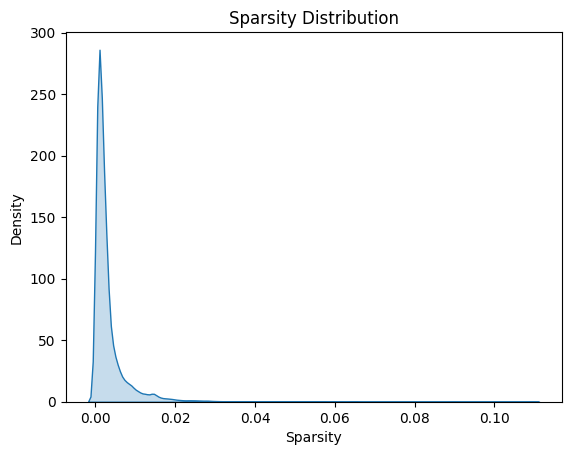

In [22]:
# plot sparsity
sns.kdeplot(data=filtered_summary_df, x="sparsity", fill=True)

plt.xlabel("Sparsity")
plt.ylabel("Density")
plt.title("Sparsity Distribution")
plt.show()